# Working with E-OBS daily gridded observations


**Last updated:** 2026-07-17

[![binder](https://mybinder.org/badge.svg)](https://mybinder.org/v2/gh/TimVlemmixKNMI/c3s-training-submodule-insitu-obs/add-eobs-training-notebook?labpath=eobs_multiple_variables.ipynb)
[![kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/TimVlemmixKNMI/c3s-training-submodule-insitu-obs/blob/add-eobs-training-notebook/eobs_multiple_variables.ipynb)
[![colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/TimVlemmixKNMI/c3s-training-submodule-insitu-obs/blob/add-eobs-training-notebook/eobs_multiple_variables.ipynb)

:::{note}
This notebook can be run on free online platforms, such as Binder, Kaggle and Colab, or they can be accessed from GitHub. The links to run this notebook in these environments are provided here, but please note they are not supported by ECMWF.
:::

## E-OBS daily gridded meteorological data

E-OBS is a daily gridded land-only observational dataset over Europe. The blended time series from the station network of the European Climate Assessment & Dataset (ECA&D) project form the basis for the E-OBS gridded dataset. The objective of this notebook is to assist first time users to obtain the data programatically and become familiar with the file format.


## Learning objectives 🎯


*What to expect from this Jupyter notebook:*

This Jupyter notebook will help you to work with E-OBS daily gridded meteorological data, which can be obtained via [this page](https://cds.climate.copernicus.eu/datasets/insitu-gridded-observations-europe?tab=overview). It will illustrate how to set up an API request and download data files from the Climate Data Store. The second part of the notebook shows how to read the data, produce maps and extract time series.

### Target audience

- **Skill level:** Beginner to intermediate
- **Role or use case:** Researchers, students, educators, and other users of gridded climate observations
- **Domain background assumed:** Basic familiarity with Python and introductory data analysis

## Prepare your environment


*Before this notebook can be run, a CDS API key needs to be installed on your system, see [how to api](https://cds.climate.copernicus.eu/how-to-api). Depending on your system, you may have to install Cartopy and Xarray.*

:::{important}
All required dependencies should be included in the `environment.yml` file.
:::

### (Install and) Import libraries


In [1]:
# Install required libraries
apply_pip_install = False  # set to True if you want to install cdsapi
if apply_pip_install:
    !pip install -q cdsapi

In [2]:
# Import your libraries here
import cdsapi
import zipfile
import xarray as xr
import glob
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import datetime

### Setup credentials (optional)


If you have not setup your `~/.cdsapirc` file with your credentials, you can replace `None` with your credentials that can be found on the [how to api](https://cds.climate.copernicus.eu/how-to-api) page (you will need to log in to see your credentials).

In [3]:
# If you have already setup your .cdsapirc file you can leave this as None
cdsapi_key = None
cdsapi_url = None

### Define your data request


The cell below illustrates how a data file can be downloaded with an API request and how to assign a file name to it. Note that a code snippet for the API request can be generated on the [same page](https://cds.climate.copernicus.eu/datasets/insitu-gridded-observations-europe?tab=download) that is also used to manually download data files. Here we chose to select multiple variables. For testing the API, it is advised to select only a single variable and the lowest grid resolution (0.25 degrees).

In [4]:
dataset = "insitu-gridded-observations-europe"
request = {
    "product_type": "ensemble_mean",
    "variable": [
        "mean_temperature",
        "precipitation_amount",
        "sea_level_pressure",
        "surface_shortwave_downwelling_radiation",
    ],
    "grid_resolution": "0_25deg",
    "period": "1980_1994",
    "version": ["33_0e"],
}

filename = f"eobs-v{request['version'][0]}-multiple_variables-{request['product_type']}-{request['grid_resolution']}-{request['period']}.zip"
client = cdsapi.Client(url=cdsapi_url, key=cdsapi_key)


# Downloading files may be slow. If the dataset has already been downloaded, leave retrieve=False to avoid downloading it again.
retrieve = False
if retrieve:
    client.retrieve(dataset, request).download(filename)

In case of E-OBS data the downloaded data file needs to be unzipped. Unzipping and saving in subfolder /eobs_data is done here below:

In [5]:
with zipfile.ZipFile(filename, "r") as zip_ref:
    zip_ref.extractall("eobs_data")

With the following optional unix command a listing is made of .nc files in the subfolder eobs_data:

In [6]:
!ls eobs_data/*.nc

eobs_data/pp_ens_mean_0.25deg_reg_1980-1994_v33.0e.nc
eobs_data/qq_ens_mean_0.25deg_reg_1980-1994_v33.0e.nc
eobs_data/rr_ens_mean_0.25deg_reg_1980-1994_v33.0e.nc
eobs_data/tg_ens_mean_0.25deg_reg_1980-1994_v33.0e.nc


## Main workflow



### Part 1: reading data to Xarray Dataset


*Here below you see how to make a list of data files, how to read a file to an Xarray Dataset and how to extract relevant attributes.*

In [7]:
eobs_datafiles = glob.glob("eobs_data/*.nc")  # generate list with all E-OBS datafiles
for file in eobs_datafiles:
    print("filename: ", file)
    ds = xr.open_dataset(file)
    var_name = list(ds.data_vars)[0]
    print("data variable:", var_name)
    print("attributes:", ds[var_name].attrs)
    print(" ")

filename:  eobs_data/pp_ens_mean_0.25deg_reg_1980-1994_v33.0e.nc
data variable: pp
attributes: {'units': 'hPa', 'long_name': 'sea level pressure', 'standard_name': 'air_pressure_at_sea_level'}
 
filename:  eobs_data/tg_ens_mean_0.25deg_reg_1980-1994_v33.0e.nc
data variable: tg
attributes: {'units': 'Celsius', 'long_name': 'mean temperature', 'standard_name': 'air_temperature'}
 
filename:  eobs_data/rr_ens_mean_0.25deg_reg_1980-1994_v33.0e.nc
data variable: rr
attributes: {'standard_name': 'thickness_of_rainfall_amount', 'long_name': 'rainfall', 'units': 'mm'}
 
filename:  eobs_data/qq_ens_mean_0.25deg_reg_1980-1994_v33.0e.nc
data variable: qq
attributes: {'standard_name': 'surface_downwelling_shortwave_flux_in_air', 'long_name': 'surface downwelling shortwave flux in air', 'units': 'W/m2'}
 


In [8]:
# specify E-OBS variable that you want to use
EOBS_VAR = "tg"  # mean temperature
# EOBS_VAR = "rr"    # rainfall
# EOBS_VAR = "pp"    # sea level pressure
# EOBS_VAR = "qq"    # surface downwelling shortwave flux in air
eobs_datafiles = glob.glob(
    f"eobs_data/*{EOBS_VAR}*.nc"
)  # find matching file (output is list with single element)
ds = xr.open_dataset(
    eobs_datafiles[0]
)  # reading first file from list to Xarray Dataset "ds"
ds.info

<bound method Dataset.info of <xarray.Dataset> Size: 2GB
Dimensions:    (time: 5479, latitude: 201, longitude: 464)
Coordinates:
  * time       (time) datetime64[ns] 44kB 1980-01-01 1980-01-02 ... 1994-12-31
  * latitude   (latitude) float64 2kB 25.38 25.62 25.88 ... 74.88 75.12 75.38
  * longitude  (longitude) float64 4kB -40.38 -40.12 -39.88 ... 75.12 75.38
Data variables:
    tg         (time, latitude, longitude) float32 2GB ...
Attributes:
    E-OBS_version:  33.0e
    Conventions:    CF-1.4
    References:     http://surfobs.climate.copernicus.eu/dataaccess/access_eo...
    history:        Tue Mar 10 17:53:48 2026: ncks -O --no-abc -d time,10957,...
    NCO:            netCDF Operators version 5.3.3 (Homepage = http://nco.sf....>

Note that longitude and latitude are provided as 1-dimensional coordinates for the regular grid on which E-OBS is defined. Extracting 1-dimensional numpy arrays for lon, lat and dates from the xarray dataset is done here below:

In [9]:
lon = ds["longitude"].values.astype(float)
lat = ds["latitude"].values.astype(float)
dates = ds["time"].values.astype("datetime64[ms]").astype(datetime)

Read variable long name and units from attributes.

In [10]:
eobs_var_longname = ds[EOBS_VAR].attrs.get("long_name")
eobs_var_units = ds[EOBS_VAR].attrs.get("units")

Extract 3D numpy array for selected E-OBS variable.

In [11]:
eobs_data_field = ds[EOBS_VAR].values  # expected shape: (dates, lat, lon)

Here below we illustrate how the dimensions of the variable data_field are ordered in relation to the coordinates "dates", "lat" and "lon".

In [12]:
print(
    np.shape(dates), np.shape(lat), np.shape(lon), np.shape(eobs_data_field)
)  # consistency check

(5479,) (201,) (464,) (5479, 201, 464)


In [13]:
# First and last day of time series
print(dates[0].strftime("%Y/%m/%d"))
print(dates[-1].strftime("%Y/%m/%d"))

1980/01/01
1994/12/31


### Part 2: maps and time series


*E-OBS data for a specified date is plotted over map of Europe. Note that the selected color map (bwr) and range (-25,25) would not be suitable for other E-OBS variables such as sealevel pressure or surface downwelling shortwave flux in air.*

In [14]:
selected_date = "1994/02/21"
index_date = np.where(dates == datetime.strptime(selected_date, "%Y/%m/%d"))[0][0]

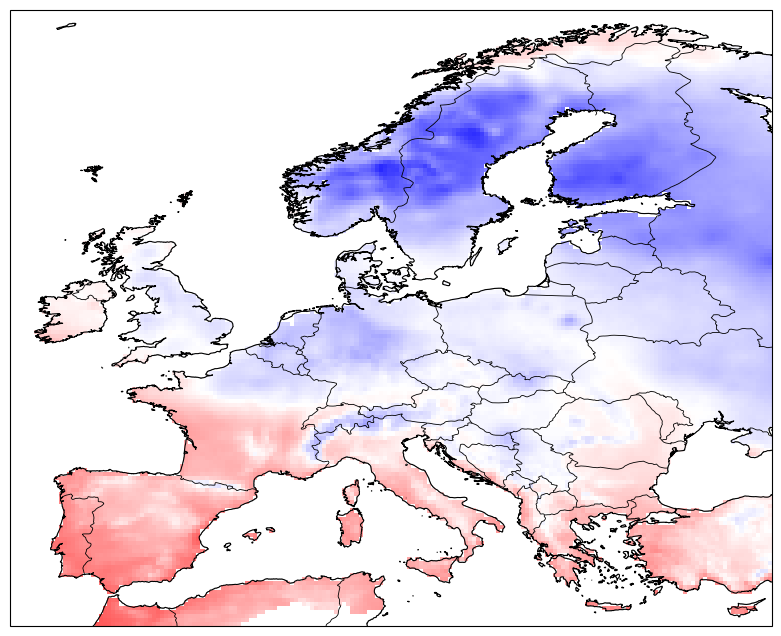

In [15]:
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-12, 35, 34, 72], crs=ccrs.PlateCarree())

mesh = ax.pcolormesh(
    lon,
    lat,
    eobs_data_field[index_date, :, :],
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="bwr",
    vmin=-25,
    vmax=25,
)

ax.coastlines(resolution="10m", linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor="none", edgecolor="black", linewidth=0.2)

In [16]:
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.4,
    color="gray",
    alpha=0.5,
    linestyle="--",
)
gl.top_labels = False
gl.right_labels = False

cbar = plt.colorbar(mesh, ax=ax, orientation="vertical", shrink=0.8)
cbar.set_label(f"{eobs_var_longname} [{eobs_var_units}]")
ax.set_title(f"E-OBS {eobs_var_longname} on {dates[index_date]:%Y/%m/%d}")

plt.show()

/var/folders/_d/3c87xn9x5377jtzpgrs0_pv80000gn/T/ipykernel_84347/3017986160.py:8: UserWarning: Adding colorbar to a different Figure <Figure size 1000x800 with 2 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(mesh, ax=ax, orientation="vertical", shrink=0.8)


<Figure size 640x480 with 0 Axes>

**Source:** E-OBS gridded observational dataset, Copernicus Climate Data Store.

Here we illustrate how to extract E-OBS time series for ground stations that are defined by a name, latitude and longitude. Please note that these stations are *not* related to the original ECA&D station data that was used in the production of the E-OBS data product.

In [17]:
stations = {
    "Reading": {"lat": 51.45, "lon": -0.98},
    "Bonn": {"lat": 50.71, "lon": 7.14},
}
start_date = "1985/01/01"
end_date = "1989/12/31"

index_date_start = np.where(dates == datetime.strptime(start_date, "%Y/%m/%d"))[0][0]
index_date_end = np.where(dates == datetime.strptime(end_date, "%Y/%m/%d"))[0][0]

station_timeseries = {}

for station_name, station in stations.items():
    index_lon = np.argmin(np.abs(lon - station["lon"]))
    index_lat = np.argmin(np.abs(lat - station["lat"]))

    station_timeseries[station_name] = eobs_data_field[
        index_date_start : index_date_end + 1,
        index_lat,
        index_lon,
    ]

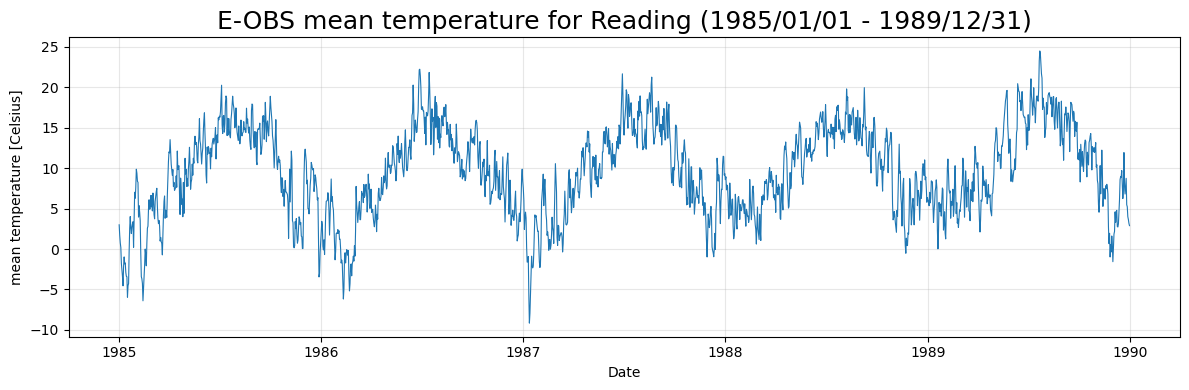

In [18]:
station_name = "Reading"

plt.figure(figsize=(12, 4))
plt.plot(
    dates[index_date_start : index_date_end + 1],
    station_timeseries[station_name],
    linewidth=0.8,
)
plt.title(
    f"E-OBS {eobs_var_longname} for {station_name} ({start_date} - {end_date})",
    fontsize=18,
)
plt.xlabel("Date")
plt.ylabel(f"{eobs_var_longname} [{eobs_var_units}]")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Take home messages 📌


- *For automated downloads: install API key*
- *E-OBS NetCDF files obtained via API need to be unzipped*
- *It is advised to load the content of the NetCDF files to Xarray Dataset objects*
- *The Xarray datasets also contain attributes with metadata such as units and long variable names*


## References


**Datasets**
- *Copernicus Climate Change Service, Climate Data Store, (2020): E-OBS daily gridded meteorological data for Europe from 1950 to present derived from in-situ observations. Copernicus Climate Change Service (C3S) Climate Data Store (CDS). [DOI](https://doi.org/10.24381/cds.151d3ec6)*

**Publications**
- *Cornes, R., van der Schrier, G., van den Besselaar, E.J.M., Jones, P., (2018): An Ensemble Version of the E-OBS Temperature and Precipitation Datasets, J. Geophys. Res. Atmos., 123. [DOI](https://doi.org/10.1029/2017JD028200)*
